In [ ]:
# # ! Setup
import numpy as np
import pyshtools as pysh
import pygmt
import time

In [ ]:
# # ! Constants
myG = 6.67430e-11
G = pysh.constants.G.value
gm_moon = pysh.constants.Moon.gm.value
r_calc = 1748000.0

In [ ]:
# # ! Shape of Moon
#### * Shape
lmax_shp = 359
clm_shp_moon = pysh.SHCoeffs.from_file(f'Moon_shape_719.sh', 
                                       lmax=lmax_shp, 
                                       name='LOLA_shape (Moon)',
                                       units='m', format='bshc')
r_itfc = clm_shp_moon.coeffs[0,0,0]

In [ ]:
# # ! Computation of topographic potential: Spectral-domain 
rho0 = 2560.0 # kg/m^3
nmaxs = np.arange(1, 7)
clms = []
for nmax in nmaxs:
    t0 = time.time()
    lmax = (lmax_shp+1)*nmax-1
    clm_topoG_moon = \
        pysh.SHGravCoeffs.from_shape(shape=clm_shp_moon,
                                     rho=rho0,
                                     gm=gm_moon,
                                     nmax=nmax,
                                     lmax=lmax,
                                     lmax_grid=lmax,
                                     lmax_calc=lmax_shp,
                                     name=f'LOLA_Topo_Grav (Moon) nmax={nmax}')
    tc = time.time() - t0
    clms.append(clm_topoG_moon)
    print(f"nmax = {nmax:2d}; lmax = {lmax:2d}; time cost: {tc:8.3f}")

nmax =  1; lmax = 359; time cost:    0.593
nmax =  2; lmax = 719; time cost:    1.607
nmax =  3; lmax = 1079; time cost:    5.703
nmax =  4; lmax = 1439; time cost:   19.025
nmax =  5; lmax = 1799; time cost:   48.425
nmax =  6; lmax = 2159; time cost:   92.958


In [ ]:
# # ! Single contribution of each nmax in a band range
print("nmax | l-beg | l-end | t-expand |  min_gz  |  max_gz  |  mean_gz |  std_gz")
for i_clm in np.arange(len(clms)):
    nmax = nmaxs[i_clm]
    if i_clm == 0:
        dif_clm = clms[i_clm]
    else:
        lmax = (lmax_shp+1)*(nmax-1)-1
        clm_1 = clms[i_clm-1]
        clm_2 = clms[i_clm]
        dif_clm = clm_2.copy()
        dif_clm.coeffs[:,:lmax+1,:lmax+1] = \
            clm_2.coeffs[:,:lmax+1,:lmax+1] - clm_1.coeffs
    for n_cut in np.arange(nmax):
        lmax1 = (lmax_shp+1)*n_cut-1
        lmax2 = (lmax_shp+1)*(n_cut+1)-1
        dif_clm.coeffs[:, :lmax1+1, :lmax1+1] = 0.0
        dif_clm.coeffs[:, lmax2+1:, lmax2+1:] = 0.0
        t0 = time.time()
        grd_sc = dif_clm.expand(a=r_calc, 
                                f=0.0,
                                lmax_calc=lmax2)
        t1 = time.time() - t0
        gz = -1.e5 * grd_sc.rad
        min_gz  = np.min(gz.data)
        max_gz  = np.max(gz.data)
        mean_gz = np.mean(gz.data)
        std_gz  = np.std(gz.data)
        fmt = ("{:4d} | {:5d} | {:5d} | {:8.4f} | "
               "{:8.3f} | {:8.3f} | {:8.3f} | {:8.3f}")
        print(fmt.format(nmax, lmax1+1, lmax2, t1,
                         min_gz, max_gz, mean_gz, std_gz))

nmax | l-beg | l-end | t-expand |  min_gz  |  max_gz  |  mean_gz |  std_gz
   1 |     0 |   359 |   0.9290 | -766.159 | 1024.164 |  -35.624 |  245.847
   2 |     0 |   359 |   1.6388 |  -59.749 |   99.169 |    0.531 |    6.800
   2 |   360 |   719 |   2.1396 |   -4.278 |    5.612 |   -0.000 |    0.415
   3 |     0 |   359 |   2.2376 |  -41.826 |   33.894 |    0.001 |    1.170
   3 |   360 |   719 |   3.4275 |   -5.498 |    6.624 |   -0.000 |    0.199
   3 |   720 |  1079 |   7.0715 |   -0.053 |    0.044 |    0.000 |    0.002
   4 |     0 |   359 |   3.2006 |  -18.451 |   12.079 |   -0.000 |    0.265
   4 |   360 |   719 |   4.9749 |   -4.460 |    5.036 |    0.000 |    0.096
   4 |   720 |  1079 |  10.2327 |   -0.113 |    0.110 |    0.000 |    0.002
   4 |  1080 |  1439 |  16.9072 |   -0.001 |    0.001 |   -0.000 |    0.000
   5 |     0 |   359 |   4.0264 |   -6.019 |    3.833 |    0.000 |    0.064
   5 |   360 |   719 |   6.4477 |   -3.138 |    3.191 |   -0.000 |    0.040
   5 |   720 

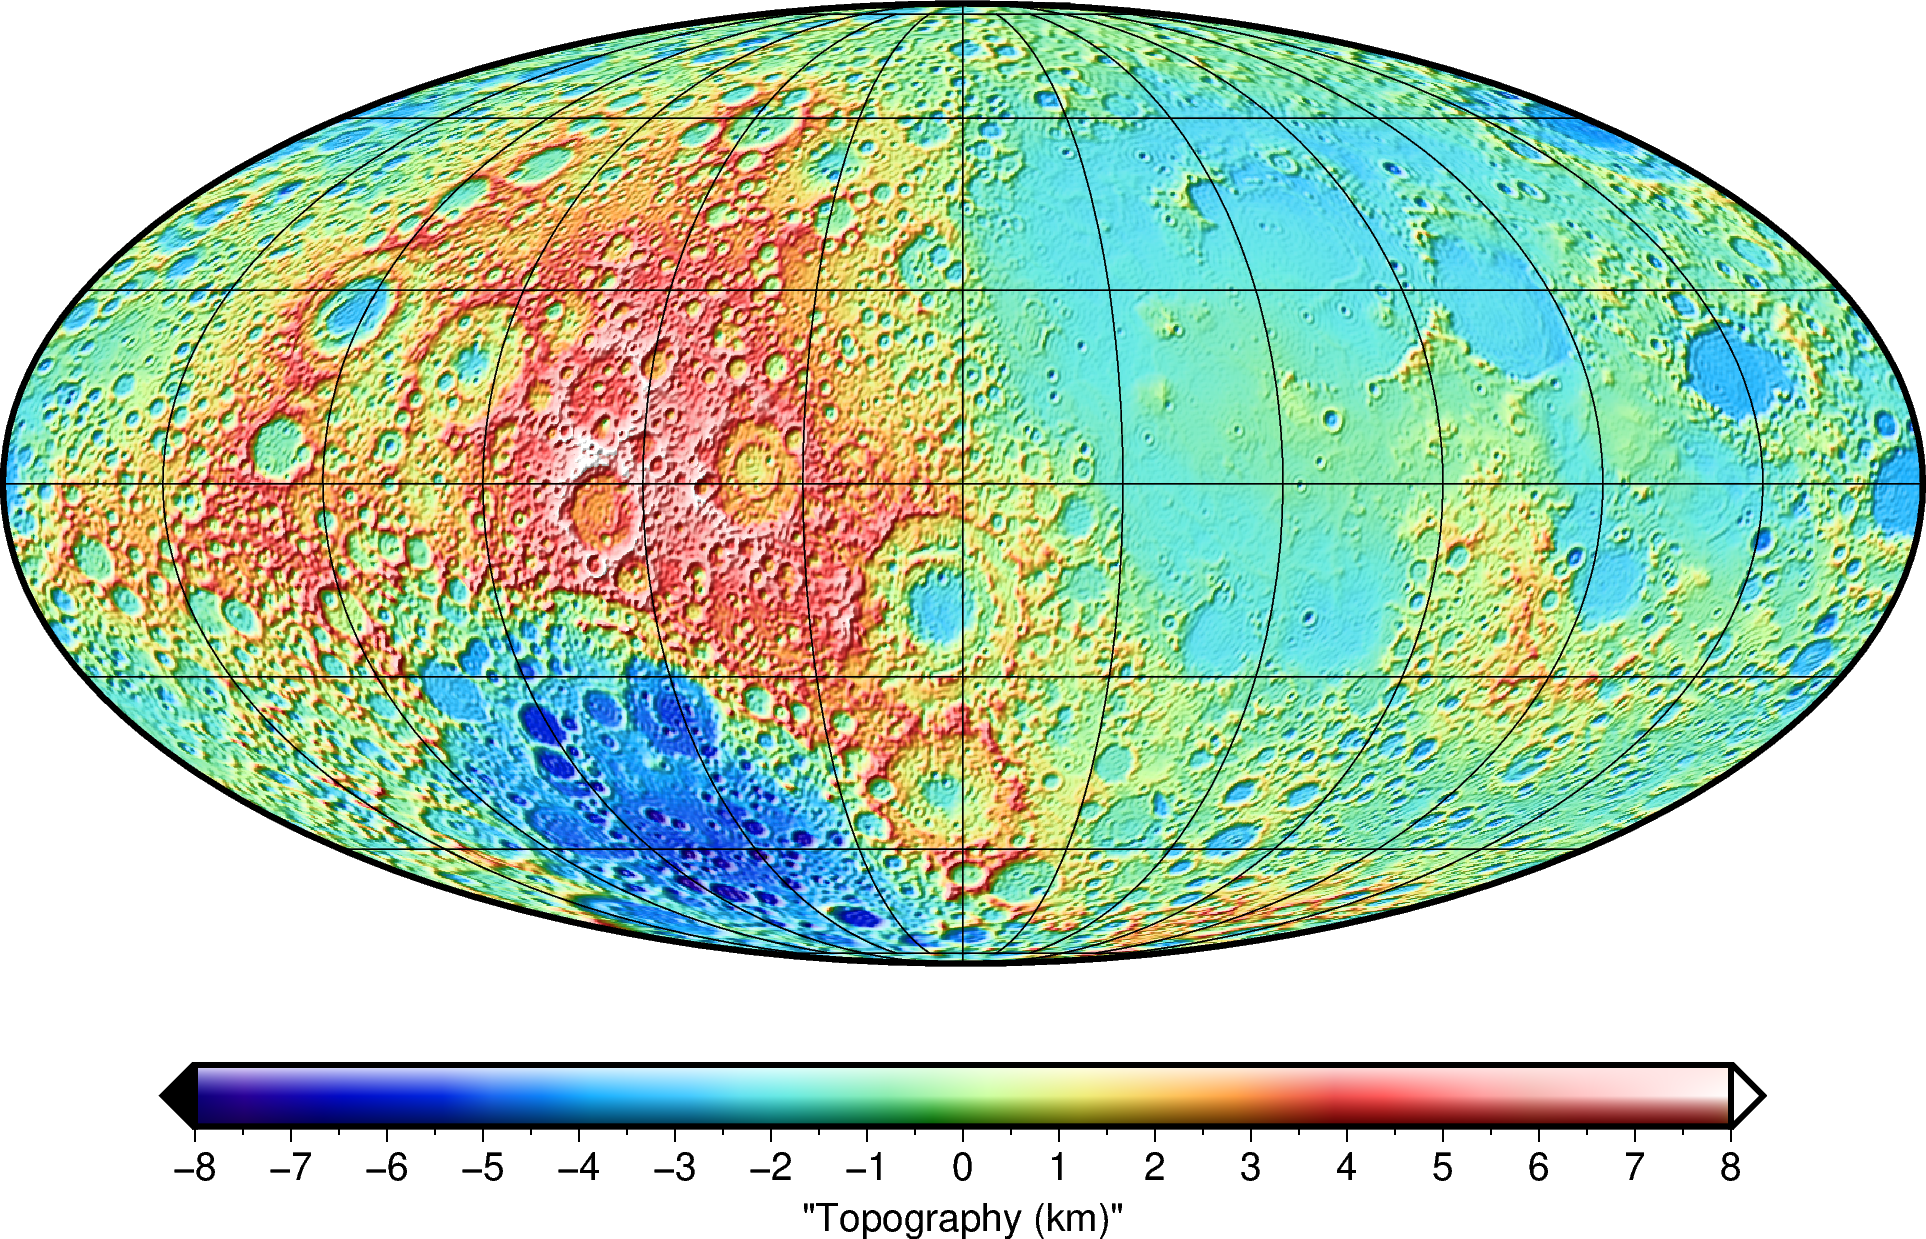

In [ ]:
# # ! Topography
#### * 
grd_shp_moon = clm_shp_moon.expand()
grd_topo_moon = (grd_shp_moon - r_itfc) / 1.e3
fig = pygmt.Figure()
grd_topo_moon.plotgmt(fig=fig,
                      projection='mollweide',
                      central_longitude=-90.,
                      grid=[30, 30],
                      tick_interval=None,
                      cmap='haxby',
                      cmap_limits=[-8, 8],
                      colorbar='bottom',
                      cb_triangles='both',
                      cb_label='Topography (km)',
                      cb_tick_interval=1,
                      cb_minor_tick_interval=0.5,
                      shading=grd_topo_moon)
fig.show(width=800)
fig.savefig('Moon_Topo.png', dpi=300)

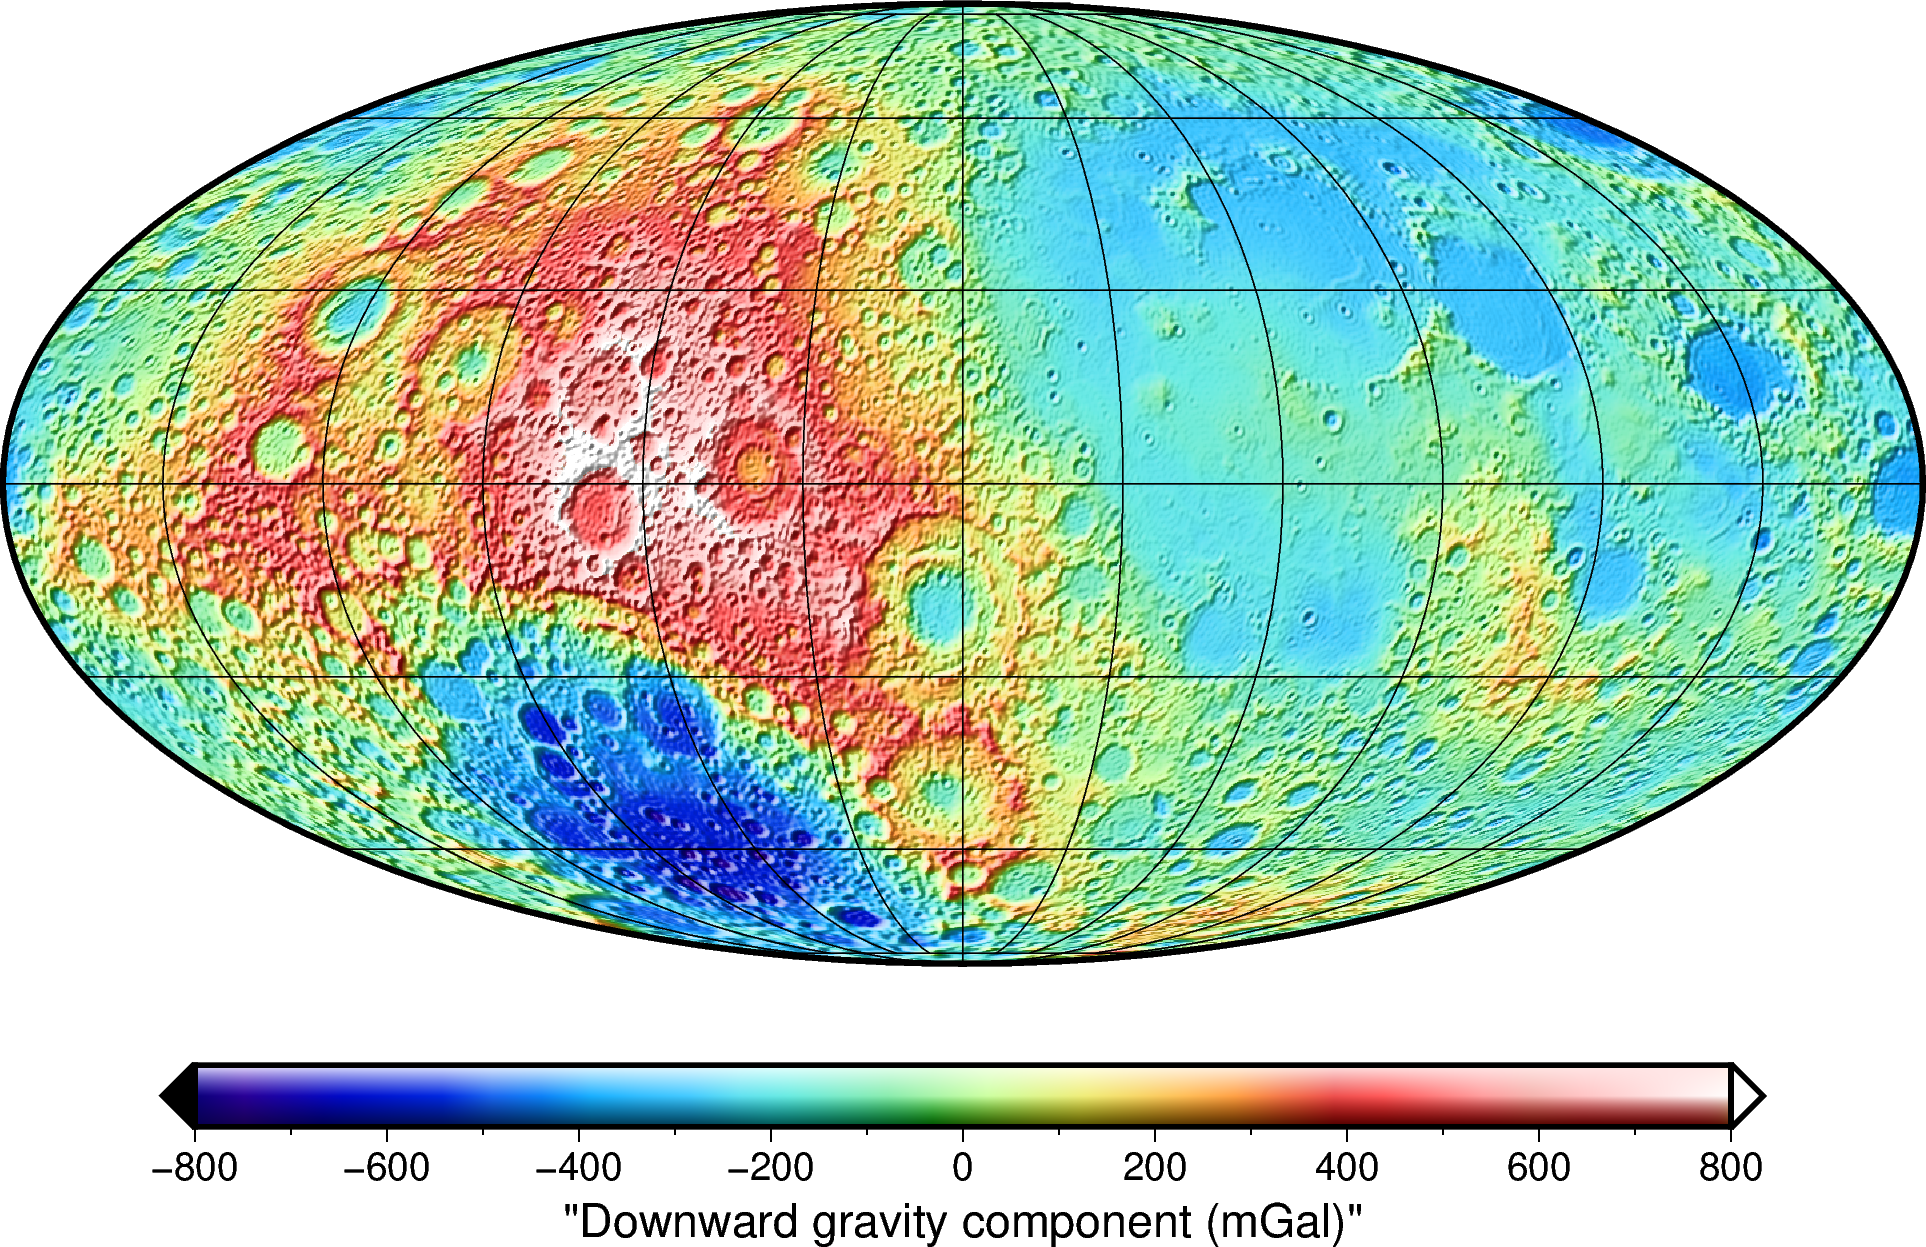

In [ ]:
# # ! Topographic potential
clm_topoG_moon = clms[0]
grd_topoG_moon = clm_topoG_moon.expand(a=r_calc, f=0.0)
gx_topoG_moon = -1.e5 * grd_topoG_moon.theta
gy_topoG_moon =  1.e5 * grd_topoG_moon.phi
gz_topoG_moon = -1.e5 * grd_topoG_moon.rad
fig = pygmt.Figure()
gz_topoG_moon.plotgmt(fig=fig,
                      projection='mollweide',
                      central_longitude=-90.,
                      grid=[30, 30],
                      tick_interval=None,
                      cmap='haxby',
                      cmap_limits=[-800, 800],
                      colorbar='bottom',
                      cb_triangles='both',
                      cb_label='Downward gravity component (mGal)',
                      axes_labelsize=12,
                      cb_tick_interval=200,
                      cb_minor_tick_interval=100,
                      shading=grd_topo_moon)
fig.show(width=800)
fig.savefig('Moon_Topo_Gz.png', dpi=300)